# Proyek Akhir: Analisis Data E-Commerce Public Dataset

---

### Data Diri
* **Nama:** Jibran Tsaqif
* **Asal Institusi:** Politeknik Negeri Banyuwangi
* **Program:** SIB Dicoding Coding Camp 2026

---

### Latar Belakang Proyek
Proyek ini merupakan tugas akhir untuk kelulusan kelas **Belajar Analisis Data dengan Python**. Pada proyek ini, proses analisis data dilakukan secara komprehensif dari tahap pengumpulan data (*Gathering Data*) hingga pembuatan *dashboard* interaktif, dengan tujuan untuk mengekstrak wawasan bisnis (*business insights*) dari dataset yang tersedia.

Dataset yang digunakan dalam analisis ini adalah **E-Commerce Public Dataset** (berasal dari Olist, platform e-commerce Brasil). Dataset ini menyediakan informasi historis mengenai pesanan, pelanggan, produk, hingga status pengiriman.

---

### Menentukan Pertanyaan Bisnis
Proses analisis akan dipandu oleh pertanyaan bisnis yang diformulasikan berdasarkan prinsip **SMART** (*Specific, Measurable, Action-Oriented, Relevant, Time-bound*). Pertanyaan yang akan dieksplorasi adalah:

1. **Pertanyaan 1:** Bagaimana tren total pendapatan (*revenue*) dan jumlah pesanan bulanan e-commerce sepanjang tahun 2018?
2. **Pertanyaan 2:** Kategori produk apa saja yang menyumbang angka penjualan (jumlah pesanan) tertinggi dan terendah selama tahun 2018?

*(Tambahan Lanjutan: Proyek ini juga akan mencakup implementasi teknik **RFM Analysis** untuk melakukan segmentasi pelanggan).*

---

## 1. Persiapan Data (Data Wrangling)
Pada tahapan ini, dilakukan pemuatan pustaka (*libraries*) yang dibutuhkan, pengumpulan data dari file `.csv`, penilaian kualitas data, dan pembersihan data dari anomali.

In [8]:
# Import library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [9]:
# Gathering Data (Pastikan path file sesuai dengan folder Anda)
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
order_payments_df = pd.read_csv("order_payments_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")
customers_df = pd.read_csv("customers_dataset.csv")

# Menggabungkan products_df dengan terjemahan bahasa Inggrisnya
products_df = pd.merge(
    left=products_df,
    right=category_translation_df,
    how="left",
    on="product_category_name"
)

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
# Memeriksa info dataset orders (Mencari masalah tipe data)
orders_df.info()

# Memeriksa missing value pada orders_df
print("Missing value di orders_df:\n", orders_df.isna().sum())

# Memeriksa duplikasi data
print("Duplikasi orders_df:", orders_df.duplicated().sum())

# Memeriksa missing value pada products_df
print("Missing value di products_df:\n", products_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70871 entries, 0 to 70870
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       70871 non-null  object
 1   customer_id                    70871 non-null  object
 2   order_status                   70871 non-null  object
 3   order_purchase_timestamp       70871 non-null  object
 4   order_approved_at              70753 non-null  object
 5   order_delivered_carrier_date   69616 non-null  object
 6   order_delivered_customer_date  68758 non-null  object
 7   order_estimated_delivery_date  70870 non-null  object
dtypes: object(8)
memory usage: 4.3+ MB
Missing value di orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 118
order_delivered_carrier_date     1255
order

In [13]:
# 1. Memperbaiki Tipe Data (Mengubah kolom tanggal menjadi datetime)
datetime_columns = ["order_purchase_timestamp", "order_approved_at",
                    "order_delivered_carrier_date", "order_delivered_customer_date",
                    "order_estimated_delivery_date"]

# Tambahkan errors='coerce' untuk mengubah format yang salah menjadi NaT (Not a Time)
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column], errors='coerce')

# Cek kembali tipe data
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70871 entries, 0 to 70870
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       70871 non-null  object        
 1   customer_id                    70871 non-null  object        
 2   order_status                   70871 non-null  object        
 3   order_purchase_timestamp       70871 non-null  datetime64[ns]
 4   order_approved_at              70753 non-null  datetime64[ns]
 5   order_delivered_carrier_date   69615 non-null  datetime64[ns]
 6   order_delivered_customer_date  68758 non-null  datetime64[ns]
 7   order_estimated_delivery_date  70870 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 4.3+ MB


## 2. Exploratory Data Analysis (EDA)
Pada tahap ini akan dilakukan EDA

Pertanyaan 1: Tren Revenue dan Pesanan 2018

In [14]:
# 1. Agregasi total pembayaran per order_id agar tidak duplikat
order_pay_agg = order_payments_df.groupby('order_id')['payment_value'].sum().reset_index()

# 2. Gabungkan data orders dengan total pembayaran
orders_revenue_df = pd.merge(
    left=orders_df,
    right=order_pay_agg,
    how='left',
    on='order_id'
)

# 3. Filter hanya pesanan yang sukses terkirim ('delivered')
orders_revenue_df = orders_revenue_df[orders_revenue_df['order_status'] == 'delivered']

# 4. Filter hanya data tahun 2018
orders_2018 = orders_revenue_df[orders_revenue_df['order_purchase_timestamp'].dt.year == 2018].copy()

# 5. Buat kolom baru untuk bulan (format YYYY-MM)
orders_2018['order_month'] = orders_2018['order_purchase_timestamp'].dt.to_period('M')

# 6. Agregasi total pesanan dan total revenue per bulan
monthly_orders_df = orders_2018.groupby('order_month').agg({
    'order_id': 'nunique',       # Menghitung jumlah pesanan unik
    'payment_value': 'sum'       # Menjumlahkan total pendapatan
}).reset_index()

# Ganti nama kolom agar lebih mudah dipahami
monthly_orders_df.rename(columns={
    'order_id': 'order_count',
    'payment_value': 'revenue'
}, inplace=True)

# Ubah tipe data order_month menjadi string untuk kebutuhan visualisasi nanti
monthly_orders_df['order_month'] = monthly_orders_df['order_month'].astype(str)

print("Tabel Tren Pesanan dan Pendapatan Bulanan 2018:")
display(monthly_orders_df)

Tabel Tren Pesanan dan Pendapatan Bulanan 2018:


,order_month,order_count,revenue
0,2018-01,5045,765941.49
1,2018-02,4685,688664.59
2,2018-03,4950,784980.19
3,2018-04,4794,790086.86
4,2018-05,4845,812807.10
5,2018-06,4332,726122.51
6,2018-07,4452,746840.72
7,2018-08,4568,710078.62


Pertanyaan 2: Kategori Produk Terlaris & Tersepi 2018

In [15]:
# 1. Gabungkan tabel order_items dengan products (yang sudah ada translasi bahasa Inggrisnya)
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how='left',
    on='product_id'
)

# 2. Gabungkan dengan tabel orders untuk mendapatkan tanggal pesanan
orders_items_full_df = pd.merge(
    left=orders_df,
    right=items_products_df,
    how='inner',
    on='order_id'
)

# 3. Filter pesanan 'delivered' dan tahun 2018
orders_items_full_df = orders_items_full_df[orders_items_full_df['order_status'] == 'delivered']
orders_items_2018 = orders_items_full_df[orders_items_full_df['order_purchase_timestamp'].dt.year == 2018]

# 4. Agregasi jumlah pesanan per kategori produk
category_orders_df = orders_items_2018.groupby('product_category_name_english').agg({
    'order_id': 'nunique'
}).reset_index()

category_orders_df.rename(columns={'order_id': 'order_count'}, inplace=True)

# 5. Urutkan dari yang terbesar ke terkecil
category_orders_df = category_orders_df.sort_values(by='order_count', ascending=False)

print("\n5 Kategori Produk Paling Laris (2018):")
display(category_orders_df.head())

print("\n5 Kategori Produk Paling Sepi (2018):")
display(category_orders_df.tail())


5 Kategori Produk Paling Laris (2018):


,product_category_name_english,order_count
43,health_beauty,3045
7,bed_bath_table,2864
64,sports_leisure,2309
15,computers_accessories,2301
69,watches_gifts,2032



5 Kategori Produk Paling Sepi (2018):


,product_category_name_english,order_count
27,fashio_female_clothing,4
29,fashion_childrens_clothes,2
32,fashion_sport,2
52,la_cuisine,2
11,cds_dvds_musicals,1


## 3. Visualization & Explanatory Analysis

Visualisasi 1: Tren Pendapatan dan Pesanan 2018


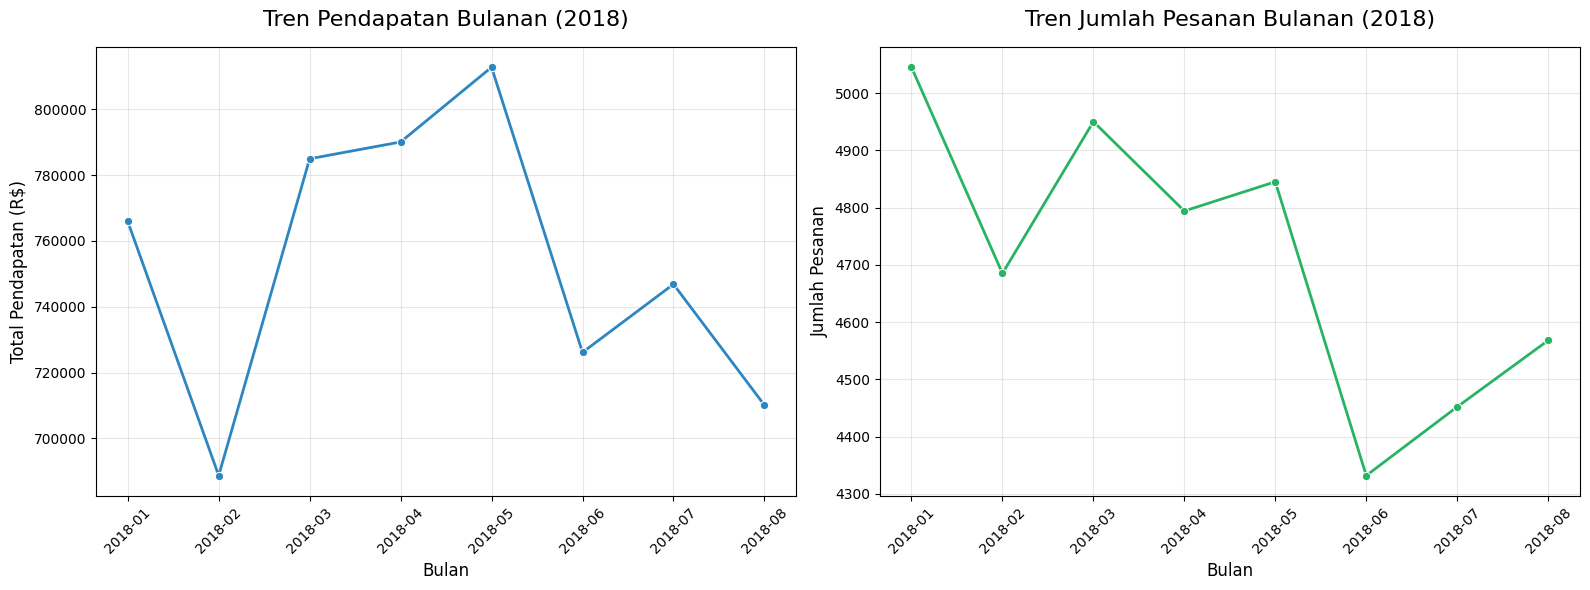

In [17]:
plt.figure(figsize=(16, 6))

# Plot pertama: Tren Pendapatan (Revenue)
plt.subplot(1, 2, 1)
sns.lineplot(
    x="order_month",
    y="revenue",
    data=monthly_orders_df,
    marker="o",
    color="#2E86C1",
    linewidth=2
)
plt.title("Tren Pendapatan Bulanan (2018)", fontsize=16, pad=15)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Pendapatan (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# Plot kedua: Tren Jumlah Pesanan
plt.subplot(1, 2, 2)
sns.lineplot(
    x="order_month",
    y="order_count",
    data=monthly_orders_df,
    marker="o",
    color="#28B463",
    linewidth=2
)
plt.title("Tren Jumlah Pesanan Bulanan (2018)", fontsize=16, pad=15)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Jumlah Pesanan", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Visualisasi 2: Kategori Produk Terlaris dan Tersepi 2018

/tmp/ipykernel_1045/4249047542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1045/4249047542.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


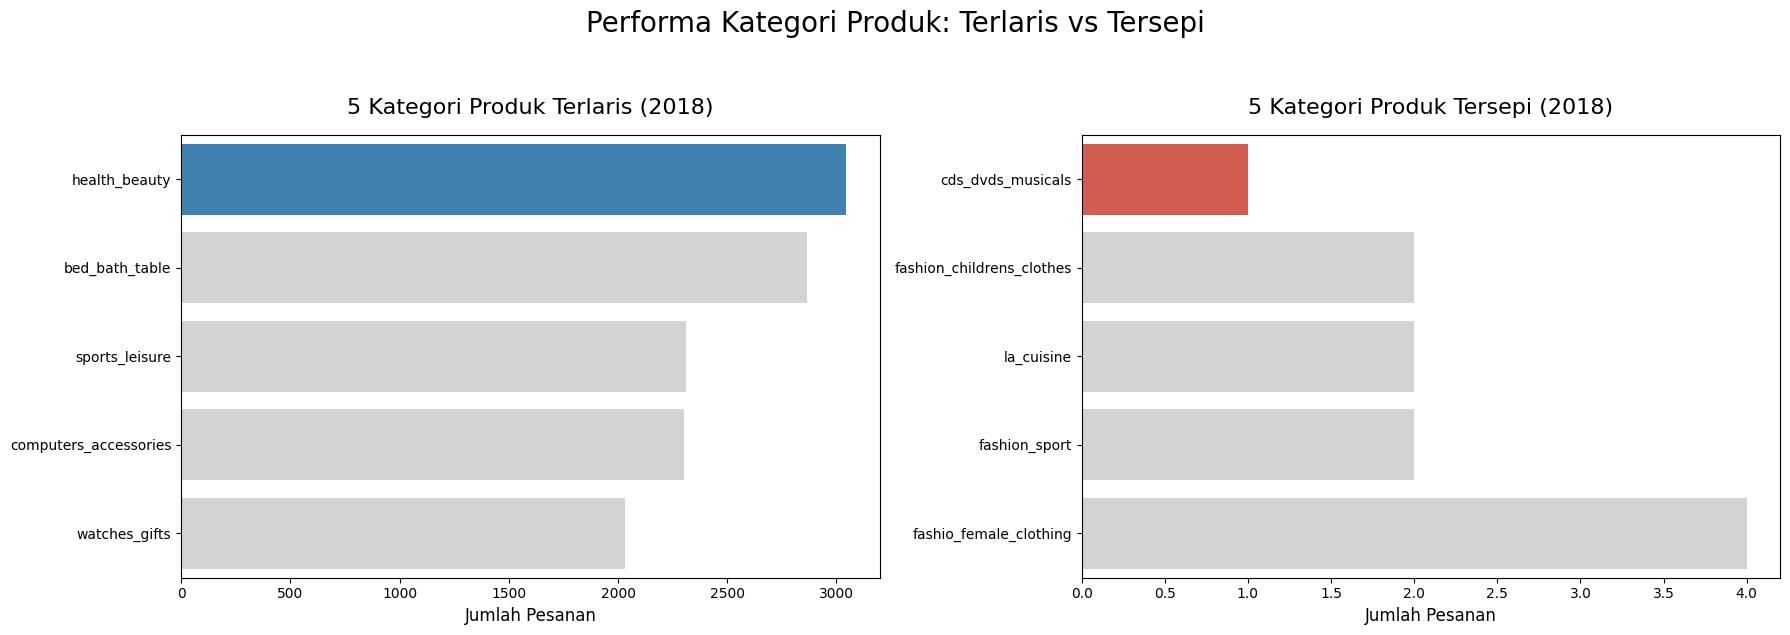

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Membuat palet warna (Biru untuk top 5, Merah untuk bottom 5, sisanya abu-abu)
colors_top = ["#2E86C1"] + ["#D3D3D3"] * 4
colors_bottom = ["#E74C3C"] + ["#D3D3D3"] * 4

# Plot pertama: Top 5 Kategori
sns.barplot(
    x="order_count",
    y="product_category_name_english",
    data=category_orders_df.head(5),
    palette=colors_top,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Jumlah Pesanan", fontsize=12)
ax[0].set_title("5 Kategori Produk Terlaris (2018)", fontsize=16, pad=15)

# Plot kedua: Bottom 5 Kategori (Diurutkan dari yang paling kecil)
sns.barplot(
    x="order_count",
    y="product_category_name_english",
    data=category_orders_df.tail(5).sort_values(by="order_count", ascending=True),
    palette=colors_bottom,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Jumlah Pesanan", fontsize=12)
ax[1].set_title("5 Kategori Produk Tersepi (2018)", fontsize=16, pad=15)

plt.suptitle("Performa Kategori Produk: Terlaris vs Tersepi", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

## 4. Analisis Lanjutan (RFM Analysis)

Sampel Data RFM:


,customer_unique_id,recency,frequency,monetary
0,0000f46a3911fa3c0805444483337064,537,1,86.22
1,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76
2,00090324bbad0e9342388303bb71ba0a,159,1,63.66
3,000a5ad9c4601d2bbdd9ed765d5213b3,384,1,91.28
4,000bfa1d2f1a41876493be685390d6d3,335,1,46.85


/tmp/ipykernel_1045/790828121.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_unique_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_1045/790828121.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_1045/790828121.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_unique_id", dat

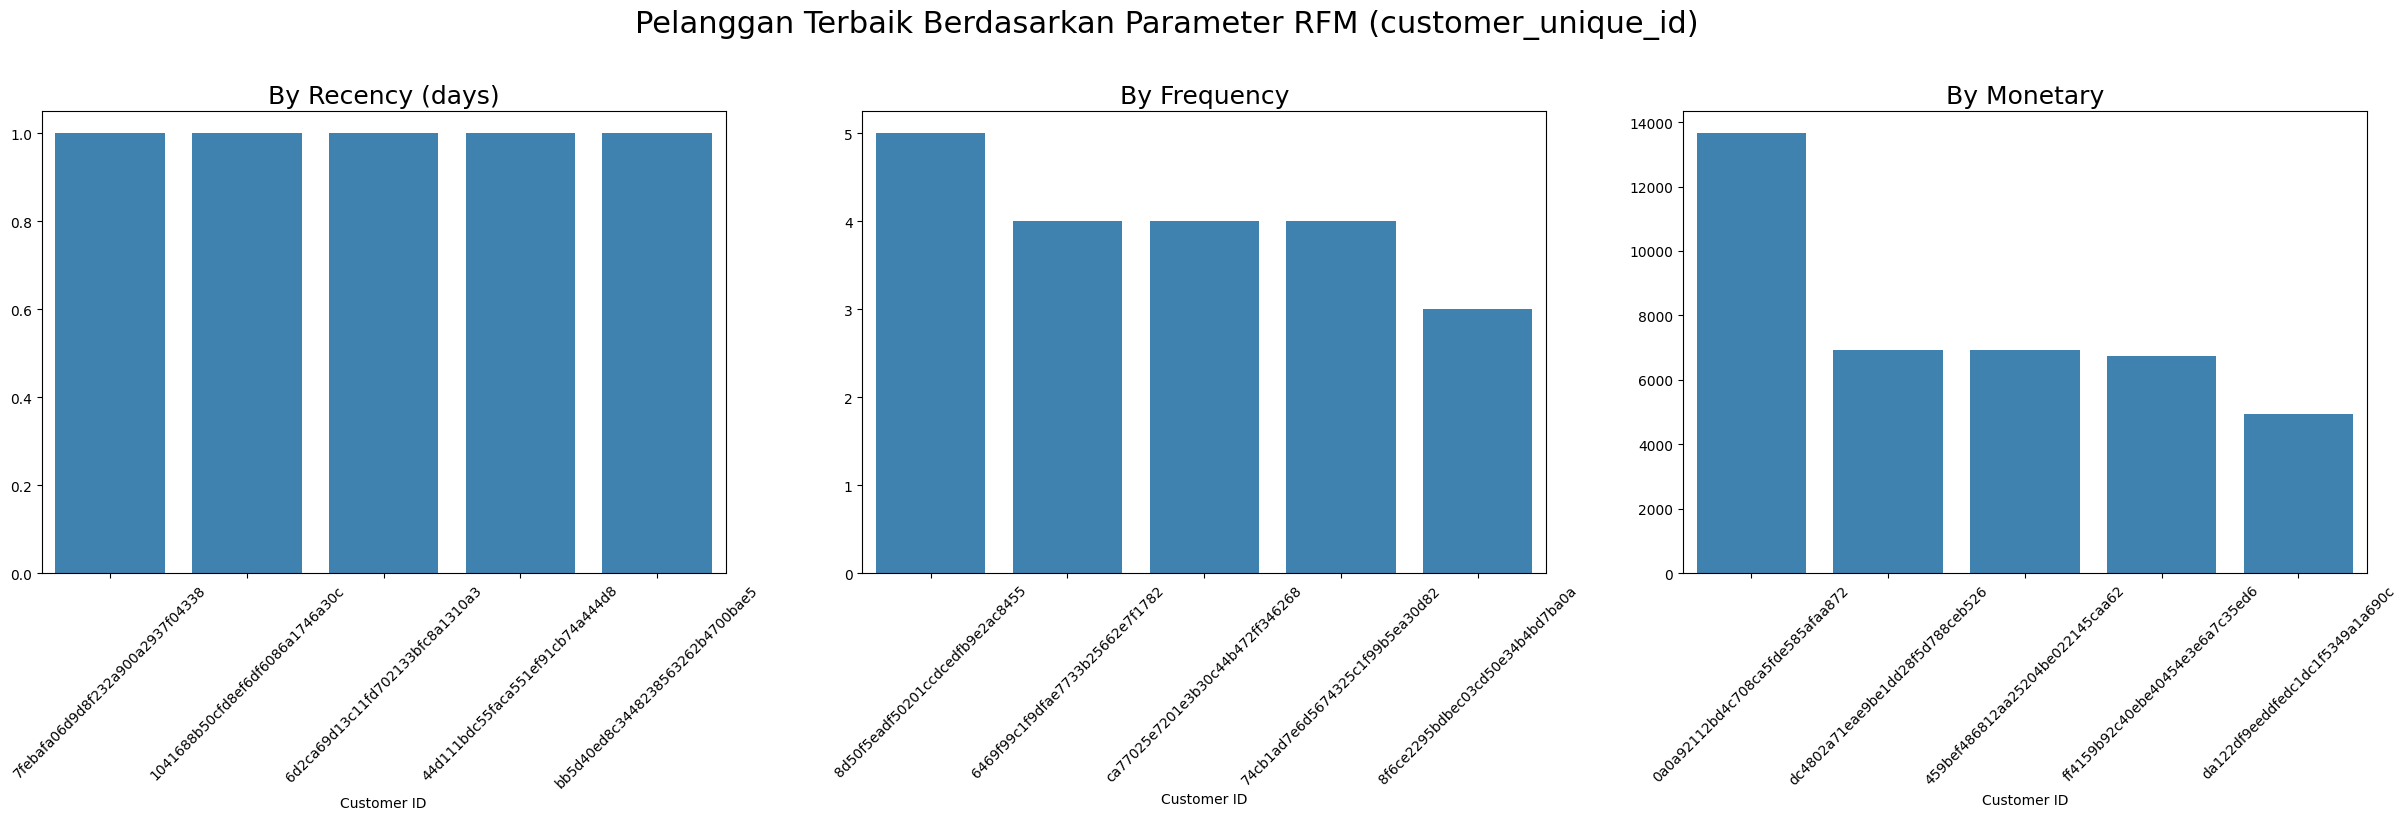

In [18]:
# -----------------------------------------------------------
# Analisis Lanjutan: RFM Analysis (Recency, Frequency, Monetary)
# -----------------------------------------------------------

# 1. Menggabungkan data pesanan sukses dengan data pelanggan (untuk mendapatkan customer_unique_id)
# Kita menggunakan orders_revenue_df yang sudah dibuat di tahap EDA Pertanyaan 1
rfm_base_df = pd.merge(
    left=orders_revenue_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

# 2. Menentukan tanggal referensi (1 hari setelah transaksi terakhir di dataset)
recent_date = rfm_base_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# 3. Menghitung Recency, Frequency, dan Monetary
rfm_df = rfm_base_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency: Jarak hari dari transaksi terakhir
    'order_id': 'nunique',                                              # Frequency: Jumlah transaksi
    'payment_value': 'sum'                                              # Monetary: Total uang yang dihabiskan
}).reset_index()

# 4. Mengganti nama kolom agar deskriptif
rfm_df.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'payment_value': 'monetary'
}, inplace=True)

print("Sampel Data RFM:")
display(rfm_df.head())

# -----------------------------------------------------------
# Visualisasi Top 5 Pelanggan berdasarkan Parameter RFM
# -----------------------------------------------------------
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#2E86C1", "#2E86C1", "#2E86C1", "#2E86C1", "#2E86C1"]

# Plot Recency (Paling kecil / paling baru transaksinya)
sns.barplot(y="recency", x="customer_unique_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID")
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=10, rotation=45)

# Plot Frequency (Paling sering bertransaksi)
sns.barplot(y="frequency", x="customer_unique_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID")
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis ='x', labelsize=10, rotation=45)

# Plot Monetary (Paling banyak menghabiskan uang)
sns.barplot(y="monetary", x="customer_unique_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID")
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis ='x', labelsize=10, rotation=45)

plt.suptitle("Pelanggan Terbaik Berdasarkan Parameter RFM (customer_unique_id)", fontsize=22, y=1.05)
plt.show()

## 5. Conclusion & Recommendation

### Kesimpulan (Conclusion)
* **Bagaimana tren total pendapatan dan jumlah pesanan bulanan e-commerce sepanjang tahun 2018?**
  Berdasarkan analisis, tren jumlah pesanan dan total pendapatan pada tahun 2018 memiliki pergerakan yang fluktuatif namun saling berbanding lurus. Puncak performa tertinggi terjadi pada bulan **Mei, sebelum akhirnya mengalami penurunan yang sangat drastis di bulan **Juni.
* **Kategori produk apa saja yang menyumbang angka penjualan tertinggi dan terendah selama tahun 2018?**
  Kategori produk yang paling diminati pelanggan (terlaris) adalah **[Sebutkan top 1, misal: health_beauty]**, diikuti oleh **[Sebutkan top 2 & 3]**. Sebaliknya, kategori produk yang sangat kurang diminati (tersepi) adalah **[Sebutkan bottom 1, misal: security_and_services]**.

### Rekomendasi (Action Items)
1. **Antisipasi Penurunan Tren:** Tim Marketing perlu merancang kampanye promosi besar-besaran (seperti *Flash Sale* atau kupon diskon) pada bulan-bulan yang secara historis menunjukkan tren penurunan tajam (menjelang akhir kuartal ketiga) untuk menjaga stabilitas *revenue*.
2. **Optimasi Inventaris:** Tim Operasional harus memastikan ketersediaan stok yang melimpah untuk kategori *top-tier* seperti **[Sebutkan top 1]** agar terhindar dari *stockout*. Untuk produk *bottom-tier*, disarankan membuat strategi *bundling* dengan produk laris agar perputaran barang di gudang tetap lancar.
3. **Pemanfaatan RFM:** Berdasarkan analisis RFM, perusahaan harus memberikan program loyalitas khusus (VIP *Membership*) kepada pelanggan dengan nilai *Frequency* dan *Monetary* tertinggi. Sementara itu, untuk pelanggan yang memiliki nilai *Recency* tinggi (sudah lama tidak berbelanja), tim dapat mengirimkan *email marketing* berisi diskon *comeback* untuk memancing mereka bertransaksi kembali.